# Lesson 3.2 — Turbulence Models

## Why One Model Doesn't Fit All

A turbulence model is an engineering compromise: it sacrifices some physical accuracy for
computational affordability. The "right" model depends on the flow:

- Free shear flows (jets, wakes): $k$-$\varepsilon$ works well
- Attached boundary layers with adverse pressure gradient: $k$-$\omega$ SST is better
- Simple attached flows: Spalart-Allmaras is fast and accurate enough
- Separated flows, massive recirculation: LES or hybrid RANS/LES

There is no universally superior RANS model.

---

## Spalart-Allmaras (SA) — One-Equation Model

Transport equation for a modified turbulent viscosity $\tilde{\nu}$:

$$\frac{D\tilde{\nu}}{Dt} = c_{b1}\tilde{S}\tilde{\nu} - c_{w1} f_w \left(\frac{\tilde{\nu}}{d}\right)^2 + \frac{1}{\sigma}\nabla\cdot\left[(\nu+\tilde{\nu})\nabla\tilde{\nu}\right]$$

Three terms: **production** (grows near walls and shear layers), **destruction** (limits growth far from walls), **diffusion**.

$d$ is the distance to the nearest wall. The model is calibrated for flat-plate boundary layers.

**When to use**: aerospace applications, attached external flows, simple BL. Fast, numerically robust.

---

## $k$-$\varepsilon$ — Two-Equation Model

Transport equations for turbulent kinetic energy $k$ and dissipation rate $\varepsilon$:

$$\frac{Dk}{Dt} = P_k - \varepsilon + \nabla\cdot\left[(\nu + \nu_t/\sigma_k)\nabla k\right]$$

$$\frac{D\varepsilon}{Dt} = \frac{\varepsilon}{k}(C_{\varepsilon 1} P_k - C_{\varepsilon 2} \varepsilon) + \nabla\cdot\left[(\nu + \nu_t/\sigma_\varepsilon)\nabla \varepsilon\right]$$

where $P_k = \nu_t S^2$ (production by mean shear), $S = |\nabla\mathbf{u}+\nabla\mathbf{u}^T|$,
and the eddy viscosity is:

$$\nu_t = C_\mu \frac{k^2}{\varepsilon}$$

Standard constants: $C_\mu = 0.09$, $C_{\varepsilon 1} = 1.44$, $C_{\varepsilon 2} = 1.92$,
$\sigma_k = 1.0$, $\sigma_\varepsilon = 1.3$.

**When to use**: free shear flows, industrial flows far from walls. Poor near walls — needs wall
functions or low-Re damping.

---

## $k$-$\omega$ SST — The Industry Standard

Menter (1994) blended $k$-$\omega$ (accurate near walls) with $k$-$\varepsilon$ (accurate in free stream):

$$\frac{Dk}{Dt} = \tilde{P}_k - \beta^* k\omega + \nabla\cdot[(\nu + \sigma_k \nu_t)\nabla k]$$

$$\frac{D\omega}{Dt} = \frac{\gamma}{\nu_t}\tilde{P}_k - \beta\omega^2 + \nabla\cdot[(\nu + \sigma_\omega \nu_t)\nabla\omega] + 2(1-F_1)\frac{\sigma_{\omega 2}}{\omega}\nabla k\cdot\nabla\omega$$

The blending function $F_1$ (= 1 near wall, 0 far from wall) switches between the two models.

**When to use**: general-purpose engineering flows with adverse pressure gradients, heat transfer,
flow separation. The default in most commercial codes.

---

## Wall Functions

Near solid walls, turbulence has a universal structure: the **law of the wall**:

- **Viscous sublayer** ($y^+ < 5$): $u^+ = y^+$
- **Log layer** ($30 < y^+ < 300$): $u^+ = \frac{1}{\kappa}\ln(y^+) + B$ (with $\kappa=0.41$, $B=5.1$)

where $u^+ = u/u_\tau$ and $y^+ = y u_\tau / \nu$, with $u_\tau = \sqrt{\tau_w/\rho}$.

**Wall functions** apply these profiles as BCs, so the first cell can sit in the log layer
($y^+ \approx 30$–100) — avoiding the need for extremely fine near-wall meshing.


/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_7101/2589107340.py:20: RuntimeWarning: overflow encountered in exp
  ek = np.exp(kappa * u)
/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_7101/2589107340.py:24: RuntimeWarning: invalid value encountered in divide
  u -= F / (dF + 1e-12)


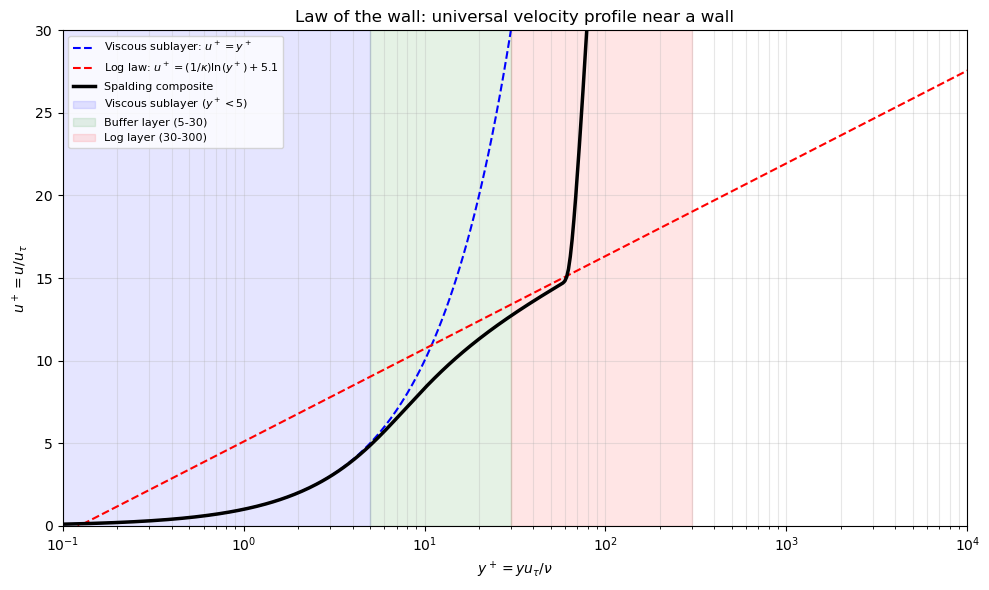

Wall functions let the first cell be at y+ ~ 30-100 (log layer).
Low-Re k-ω SST resolves all the way to y+ ~ 1 (viscous sublayer).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# The law of the wall
kappa = 0.41
B     = 5.1
y_plus = np.logspace(-1, 4, 500)

# Viscous sublayer
u_visc = y_plus
# Log layer
u_log  = (1/kappa) * np.log(y_plus) + B

# Blended (Spalding composite profile)
def spalding(y_plus):
    """Spalding's single formula valid across all y+"""
    # Solve implicitly: y+ = u+ + exp(-B*kappa)*(exp(k*u+)-1-k*u+-0.5*(k*u+)^2-1/6*(k*u+)^3)
    u = y_plus.copy()
    for _ in range(20):  # Newton iteration
        ek = np.exp(kappa * u)
        F  = u + np.exp(-kappa*B)*(ek - 1 - kappa*u - 0.5*(kappa*u)**2
                                  - (kappa*u)**3/6) - y_plus
        dF = 1 + np.exp(-kappa*B)*(kappa*ek - kappa - kappa**2*u - 0.5*kappa**3*u**2)
        u -= F / (dF + 1e-12)
    return u

u_spalding = spalding(y_plus)

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(y_plus, u_visc,     'b--', linewidth=1.5, label='Viscous sublayer: $u^+=y^+$')
ax.semilogx(y_plus, u_log,      'r--', linewidth=1.5, label=f'Log law: $u^+=(1/\\kappa)\\ln(y^+)+{B}$')
ax.semilogx(y_plus, u_spalding, 'k-',  linewidth=2.5, label='Spalding composite')

ax.axvspan(0, 5,    alpha=0.1, color='blue',  label='Viscous sublayer ($y^+ < 5$)')
ax.axvspan(5, 30,   alpha=0.1, color='green', label='Buffer layer (5-30)')
ax.axvspan(30, 300, alpha=0.1, color='red',   label='Log layer (30-300)')

ax.set_xlim(0.1, 1e4)
ax.set_ylim(0, 30)
ax.set_xlabel('$y^+ = y u_\\tau / \\nu$')
ax.set_ylabel('$u^+ = u / u_\\tau$')
ax.set_title('Law of the wall: universal velocity profile near a wall')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("Wall functions let the first cell be at y+ ~ 30-100 (log layer).")
print("Low-Re k-ω SST resolves all the way to y+ ~ 1 (viscous sublayer).")

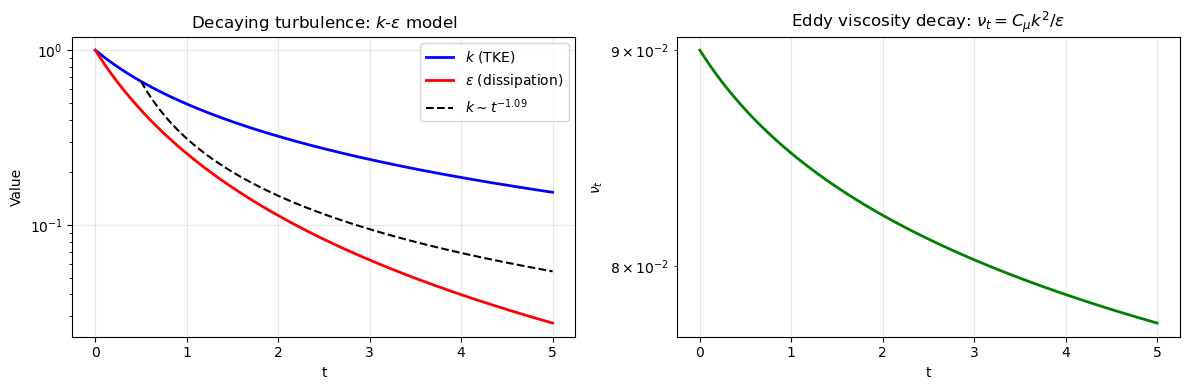

In [2]:
# Simple k-epsilon model for decaying turbulence (zero-dimensional ODE)
# dk/dt = -epsilon
# depsilon/dt = -C_e2 * epsilon^2 / k
# Exact: k ~ t^(-n), epsilon ~ t^(-n-1) with n = 1/(C_e2 - 1) ~ 1.23

C_e2 = 1.92
dt = 0.001
t_end = 5.0

# Initial conditions
k0 = 1.0
eps0 = 1.0  # initial dissipation

t_arr = [0.0]
k_arr = [k0]
e_arr = [eps0]

k, eps = k0, eps0
t = 0.0
while t < t_end:
    dk  = -eps
    de  = -C_e2 * eps**2 / k
    k   = max(k + dt*dk, 1e-10)
    eps = max(eps + dt*de, 1e-10)
    t  += dt
    t_arr.append(t)
    k_arr.append(k)
    e_arr.append(eps)

t_arr = np.array(t_arr)
k_arr = np.array(k_arr)
e_arr = np.array(e_arr)

# Analytical power-law decay
n = 1.0 / (C_e2 - 1)
t_ref = t_arr[t_arr > 0.5]
k_analytical = k_arr[t_arr > 0.5][0] * (t_ref / t_ref[0])**(-n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(t_arr, k_arr, 'b-', linewidth=2, label='$k$ (TKE)')
axes[0].semilogy(t_arr, e_arr, 'r-', linewidth=2, label='$\\varepsilon$ (dissipation)')
axes[0].semilogy(t_ref, k_analytical, 'k--', linewidth=1.5, label=f'$k \\sim t^{{-{n:.2f}}}$')
axes[0].set_xlabel('t'); axes[0].set_ylabel('Value')
axes[0].set_title('Decaying turbulence: $k$-$\\varepsilon$ model')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Turbulent Reynolds number
nu_t = 0.09 * k_arr**2 / (e_arr + 1e-10)
axes[1].semilogy(t_arr, nu_t, 'g-', linewidth=2)
axes[1].set_xlabel('t'); axes[1].set_ylabel('$\\nu_t$')
axes[1].set_title('Eddy viscosity decay: $\\nu_t = C_\\mu k^2/\\varepsilon$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Selection Guide

| Flow type | Recommended model |
|-----------|-------------------|
| Aerodynamic BL (attached, low AoA) | Spalart-Allmaras |
| Internal flows (pipes, ducts) | Realizable $k$-$\varepsilon$ |
| External with separation | $k$-$\omega$ SST |
| Buoyancy-driven flows | $k$-$\varepsilon$ RNG |
| Rotating machinery | $k$-$\omega$ SST or realizable $k$-$\varepsilon$ |
| Anything with strong swirl/rotation | Reynolds Stress Model (RSM) |

## Key Takeaways

- Turbulence models close the RANS equations by approximating $-\overline{u'u'}$.
- Boussinesq: $-\overline{u'u'} \approx \nu_t \times$ mean strain — simple but not universal.
- SA (1-eq): fast, aerospace BLs. $k$-$\varepsilon$ (2-eq): free shear flows. $k$-$\omega$ SST (2-eq): general.
- $y^+$ controls whether you use wall functions (y+ ~ 30-100) or low-Re meshing (y+ ~ 1).
- No RANS model is accurate for all flows — always validate against experiments.

---

**Next**: Lesson 3.3 — Mesh Generation: structured vs unstructured, quality metrics, refinement.
